# nanoGPT language modeling

Sven vs the modern LM optimizers (AdamW/Muon/SOAP) on char-level tiny-shakespeare. Validation loss -> perplexity vs epoch and wall-time.

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/nanogpt'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
df = add_derived(load_results('exp_nanogpt_speedrun'))
best = best_per_method(df, by='final_val_loss')   # best CONFIG per optimizer, by seed-mean val loss

Loaded 48 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)


### Val / train loss of each optimizer's best config (seed mean, band = seed spread)

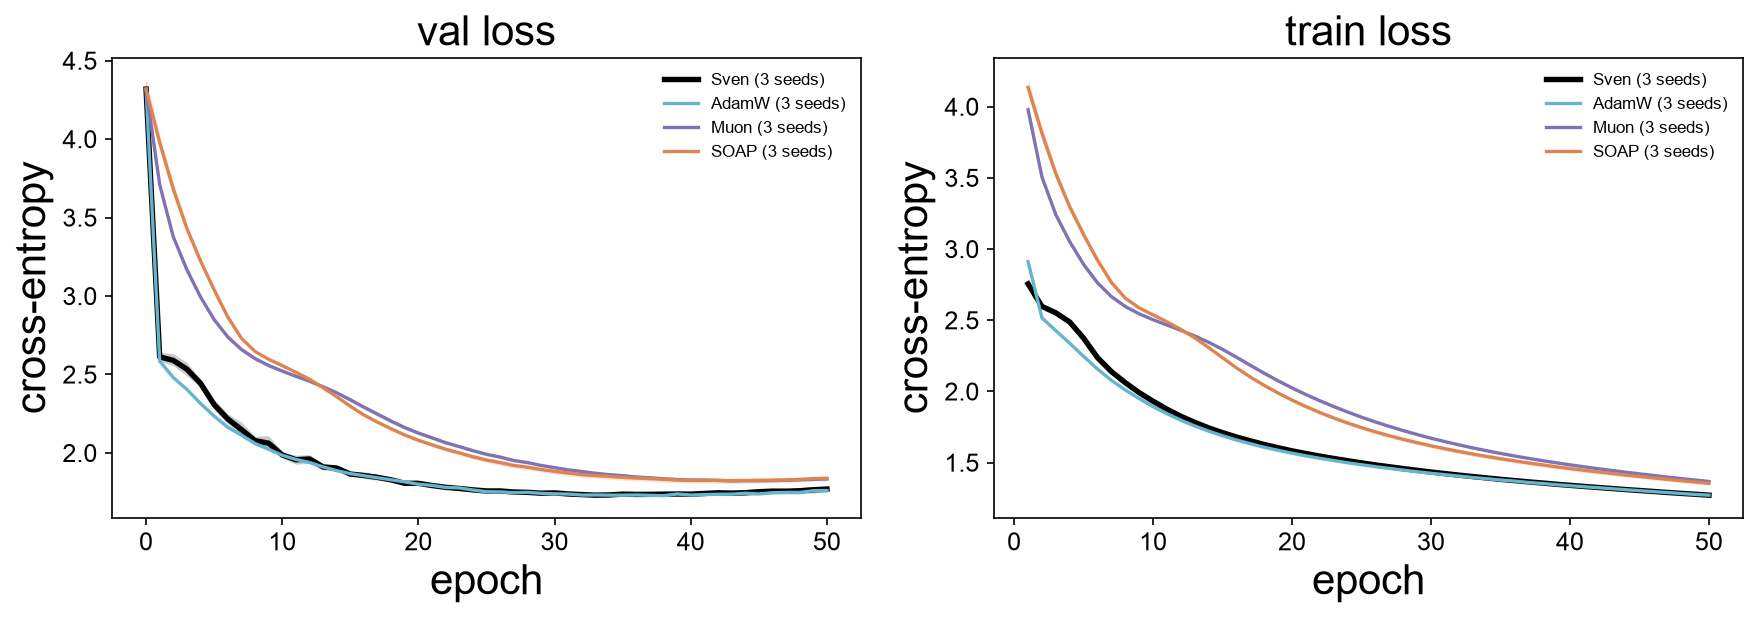

In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for m in method_order(best['method'].unique()):
    runs=config_runs(df, best[best.method==m].iloc[0])
    for ax,which in zip(axes,['val','train']):
        mean,lower,upper=seed_band(runs, which)
        if mean is None: continue
        x=np.arange(len(mean)) if which=='val' else np.arange(1,len(mean)+1)   # val has a pre-training entry
        ax.plot(x, mean, color=sven_color(m), lw=sven_lw(m), label=f'{m} ({len(runs)} seeds)')
        ax.fill_between(x, lower, upper, color=sven_color(m), alpha=0.2, lw=0)
axes[0].set_title('val loss'); axes[1].set_title('train loss')
for ax in axes: ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'nanogpt_curves.pdf',bbox_inches='tight'); plt.show()

### Summary (best config per optimizer; mean ± std over seeds)

Wall time is the **standalone** (one run per GPU) timing where available; the scan's own
`total_time` is inflated by shard contention.

In [4]:
import scan_analysis as sa
scan = sa.load_scan('exp_nanogpt_speedrun', DATASET_TITLES['nanogpt'], 'plots_v2/nanogpt')
NB_BASELINES = [b for b in ['AdamW', 'Muon', 'MuonW', 'SOAP'] if b in scan.baselines]
timing = sa.attach_standalone_times(scan)
summary = sa.summary_table(scan, baselines=NB_BASELINES)
summary['val_ppl'] = np.exp(summary['final_val_loss'])
cols = ['method','config','n_seeds','n_diverged','final_val_loss','final_val_loss_std','val_ppl',
        'sharded_time_s','standalone_time_s']
summary[[c for c in cols if c in summary]]

Loaded 48 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 48 runs  |  B=64, 50 epochs, 3 seeds  |  Sven k=[64] rtol=[0.001]
Loaded 12 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_timing.slim.pkl (slim cache)
[standalone] 12 runs in exp_nanogpt_speedrun_timing/, 12 joined; final-val-loss deviation vs scan: max 0.00e+00, median 0.00e+00


,method,config,n_seeds,n_diverged,final_val_loss,final_val_loss_std,val_ppl,sharded_time_s,standalone_time_s
0,AdamW,lr=0.0003,3,0,1.760126,0.011873,5.813167,158.296240,154.423781
1,Sven,"k=64, lr=0.1, rtol=0.001",3,0,1.769380,0.019165,5.867213,553.812351,524.358226
2,Muon,lr=0.0003,3,0,1.833589,0.000995,6.256301,206.826718,199.067858
3,SOAP,lr=0.0001,3,0,1.837899,0.014817,6.283323,260.486897,256.483390


### Honest wall time: standalone runs (scan_analysis)

Best config per optimizer re-run alone on a GPU with the same seeds
(`experiment_results/exp_nanogpt_speedrun_timing/`); joined by run_id.

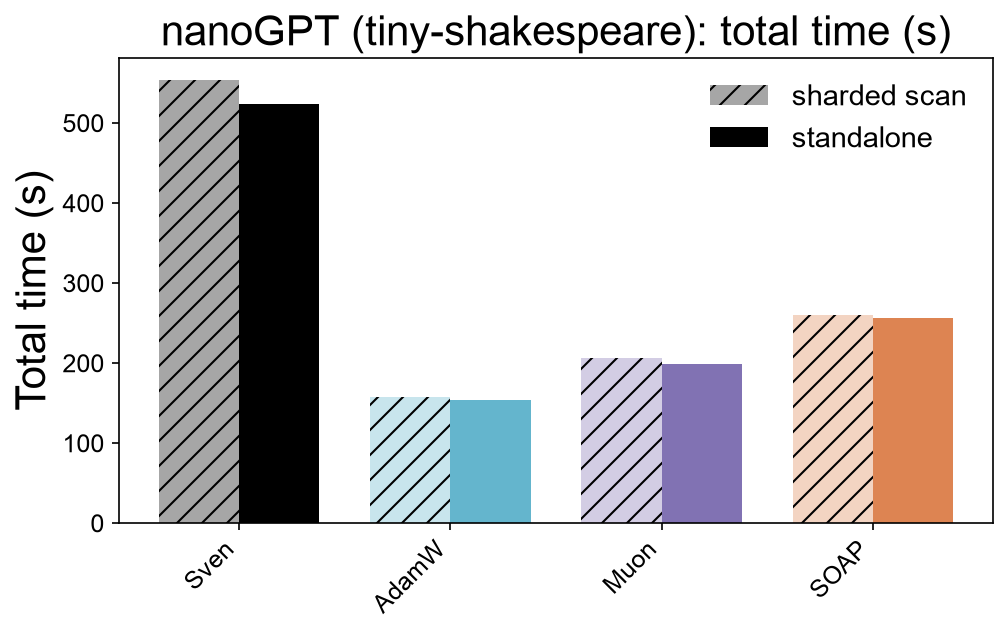

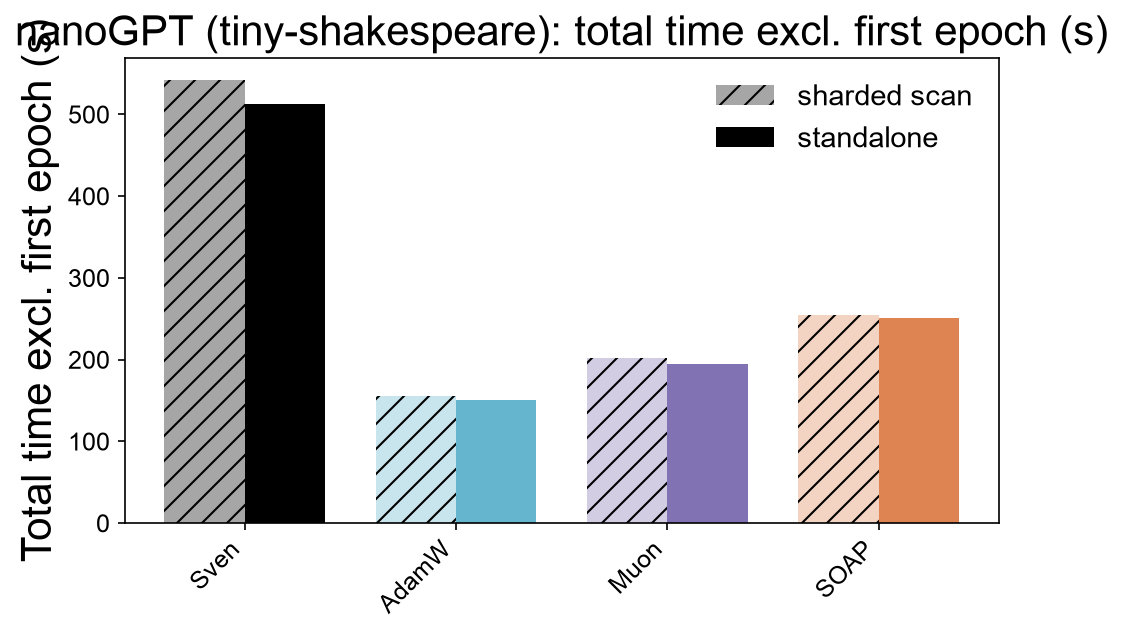

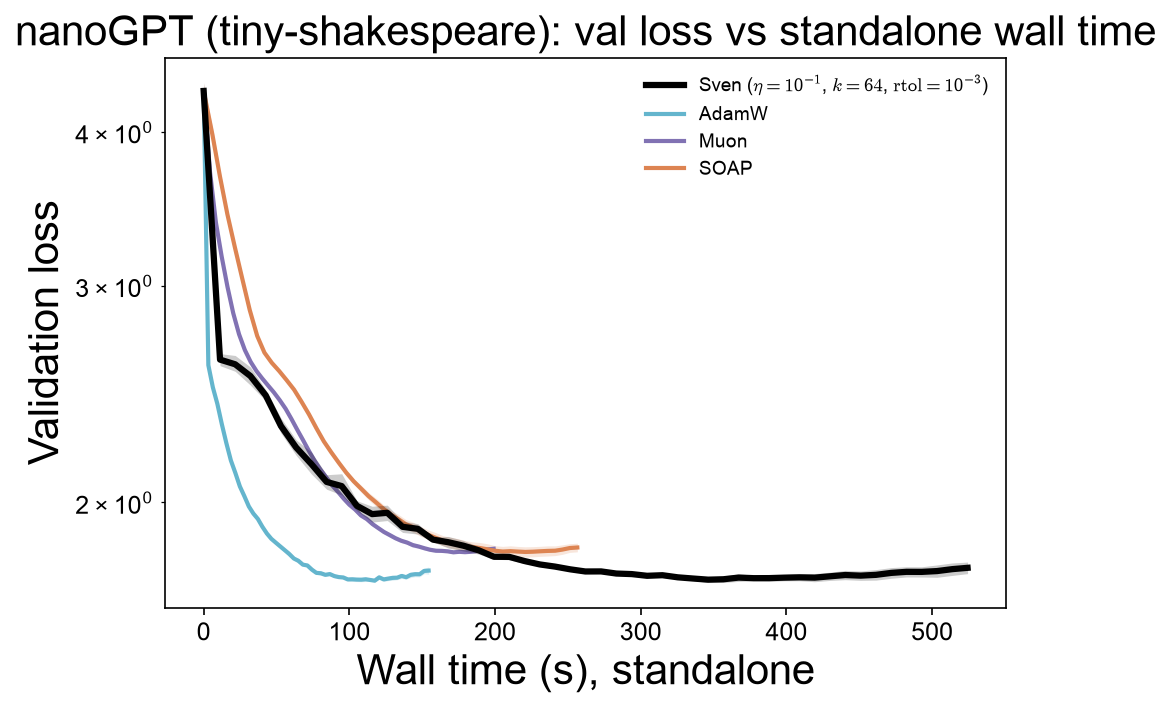

In [5]:
if timing is not None:
    for quantity, ylabel in [('total_time', 'Total time (s)'),
                             ('time_excl_first_epoch', 'Total time excl. first epoch (s)')]:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        sa.plot_time_comparison(scan, ax, quantity, baselines=NB_BASELINES)
        ax.set_ylabel(ylabel); ax.set_title(f'{scan.title}: {ylabel.lower()}')
        fig.tight_layout(); scan.save(fig, f'standalone_{quantity}.pdf'); plt.show()
    fig, ax = plt.subplots(figsize=(7, 5))
    sa.plot_best_curves(scan, ax, which='val', versus='time', baselines=NB_BASELINES,
                        time_key='epoch_times_standalone')
    ax.set_title(f'{scan.title}: val loss vs standalone wall time'); ax.legend(fontsize=9)
    fig.tight_layout(); scan.save(fig, 'standalone_walltime_vs_val_loss.pdf'); plt.show()